### **Recurrent Neural Networks (RNNs), and the Exploding and Vanishing Gradient Problems**

### **Dataset used**
This project uses the SketchRNN Dataset, a large-scale collection of hand-drawn sketches from the "Quick, Draw!" game.

Each sketch is represented as a sequence of pen strokes, including coordinates and pen-state information. These sequential representations are used as inputs to an RNN-based classification model, which learns to classify sketches into their corresponding categories.

### **Download and load data**

In [1]:
import os
import urllib.request
import numpy as np

classes = ['apple', 'cat', 'bicycle', 'airplane', 'banana']
save_dir = "./data"

os.makedirs(save_dir, exist_ok=True)

data = {}

for category in classes:
    file_name = f"{category}.npz"
    file_path = os.path.join(save_dir, file_name)
    url = f"https://storage.googleapis.com/quickdraw_dataset/sketchrnn/{file_name}"

    if not os.path.exists(file_path):
        print("Downloading data:", file_name)
        urllib.request.urlretrieve(url, file_path)
    else:
        print(f"Data {file_name} is already existed.")

    loaded_data = np.load(file_path, encoding='latin1', allow_pickle=True)
    data[category] = {
        'train': loaded_data['train'],
        'valid': loaded_data['valid'],
        'test': loaded_data['test']
    }

print("All datas are loaded.")

Data apple.npz is already existed.


c:\Program Files\Python311\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Data cat.npz is already existed.
Data bicycle.npz is already existed.
Data airplane.npz is already existed.
Data banana.npz is already existed.
All datas are loaded.


### **Describe Data**

Max stroke length: 129
Min stroke length: 14
Mean stroke length: 52


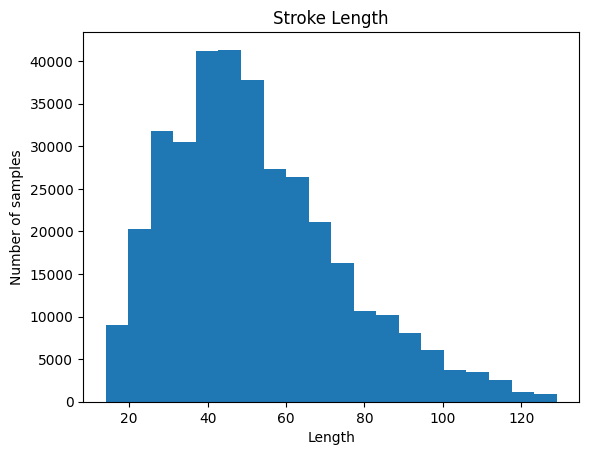

In [2]:
import matplotlib.pyplot as plt

lengths = []
for category in classes:
    for stroke in data[category]['train']:
        lengths.append(len(stroke))

print(f"Max stroke length: {max(lengths)}")
print(f"Min stroke length: {min(lengths)}")
print(f"Mean stroke length: {int(np.mean(lengths))}")

plt.hist(lengths, bins=20)
plt.title("Stroke Length")
plt.xlabel("Length")
plt.ylabel("Number of samples")
plt.show()

View one sample

In [3]:
sample_sketch = data['apple']['train'][0]

print("Overall information:")
print(f"- Shape: {sample_sketch.shape}")
print(f"- Data type: {sample_sketch.dtype}")

print("\nData:")
print("-" * 28)
print(f"{'dx':>8} {'dy':>8} {'p (pen)':>8}")
print("-" * 28)

for row in sample_sketch:
    print(f"{row[0]:8d} {row[1]:8d} {row[2]:8d}")

print("-" * 28)

print("\nUnique p:")
unique_p, counts_p = np.unique(sample_sketch[:, 2], return_counts=True)
for value, count in zip(unique_p, counts_p):
    print(f"- Value: {value} - Count: {count}")

print("\ndx, dy range:")
print(f"- dx: from {sample_sketch[:, 0].min()} to {sample_sketch[:, 0].max()}")
print(f"- dy: from {sample_sketch[:, 1].min()} to {sample_sketch[:, 1].max()}")

Overall information:
- Shape: (43, 3)
- Data type: int16

Data:
----------------------------
      dx       dy  p (pen)
----------------------------
     -17      -18        0
     -19      -14        0
     -32       -2        0
     -13        5        0
     -17       11        0
      -9       11        0
      -9       48        0
       3       32        0
       9       15        0
      64       70        0
       9       45        0
      10       10        0
      19        3        0
      12      -15        0
      22        0        0
      10        6        0
       5       -2        0
      15      -34        0
      37      -37        0
       5      -10        0
       6      -15        0
       6      -33        0
       2      -37        0
      -5      -13        0
     -12      -15        0
     -48      -33        0
     -13       -1        0
     -14        6        0
     -18       15        0
      -5        8        1
       3      -19        0
      -1      

Plot sketch

In [4]:
def plot_sketch(sketch, ax, title=""):
    # Split the sequence into individual strokes
    strokes = []
    current_stroke = []
    x, y = 0, 0

    for dx, dy, p in sketch:
        x += dx
        y += dy
        current_stroke.append([x, y])
        if p == 1: # pen lifted
            strokes.append(np.array(current_stroke))
            current_stroke = []
            
    if len(current_stroke) > 0:
        strokes.append(np.array(current_stroke))

    # A color palette for distinguishing different strokes
    colors = plt.cm.tab10.colors

    for i, stroke in enumerate(strokes):
        color = colors[i % len(colors)]

        # Draw the strokes with connecting lines and dots at each point
        if len(stroke) > 1:
            ax.plot(
                stroke[:, 0], stroke[:, 1], 
                color=color, linestyle='-', linewidth=1.5, 
                marker='.', markersize=4
            )
        else:
            # Stroke is only one point
            ax.plot(
                stroke[0, 0], stroke[0, 1], 
                color=color, marker='.', markersize=4
            )

    ax.invert_yaxis()  # Invert the Y-axis to display the image in the correct orientation (not upside down) because the dataset and matplotlib use different coordinate system
    ax.axis('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=10)

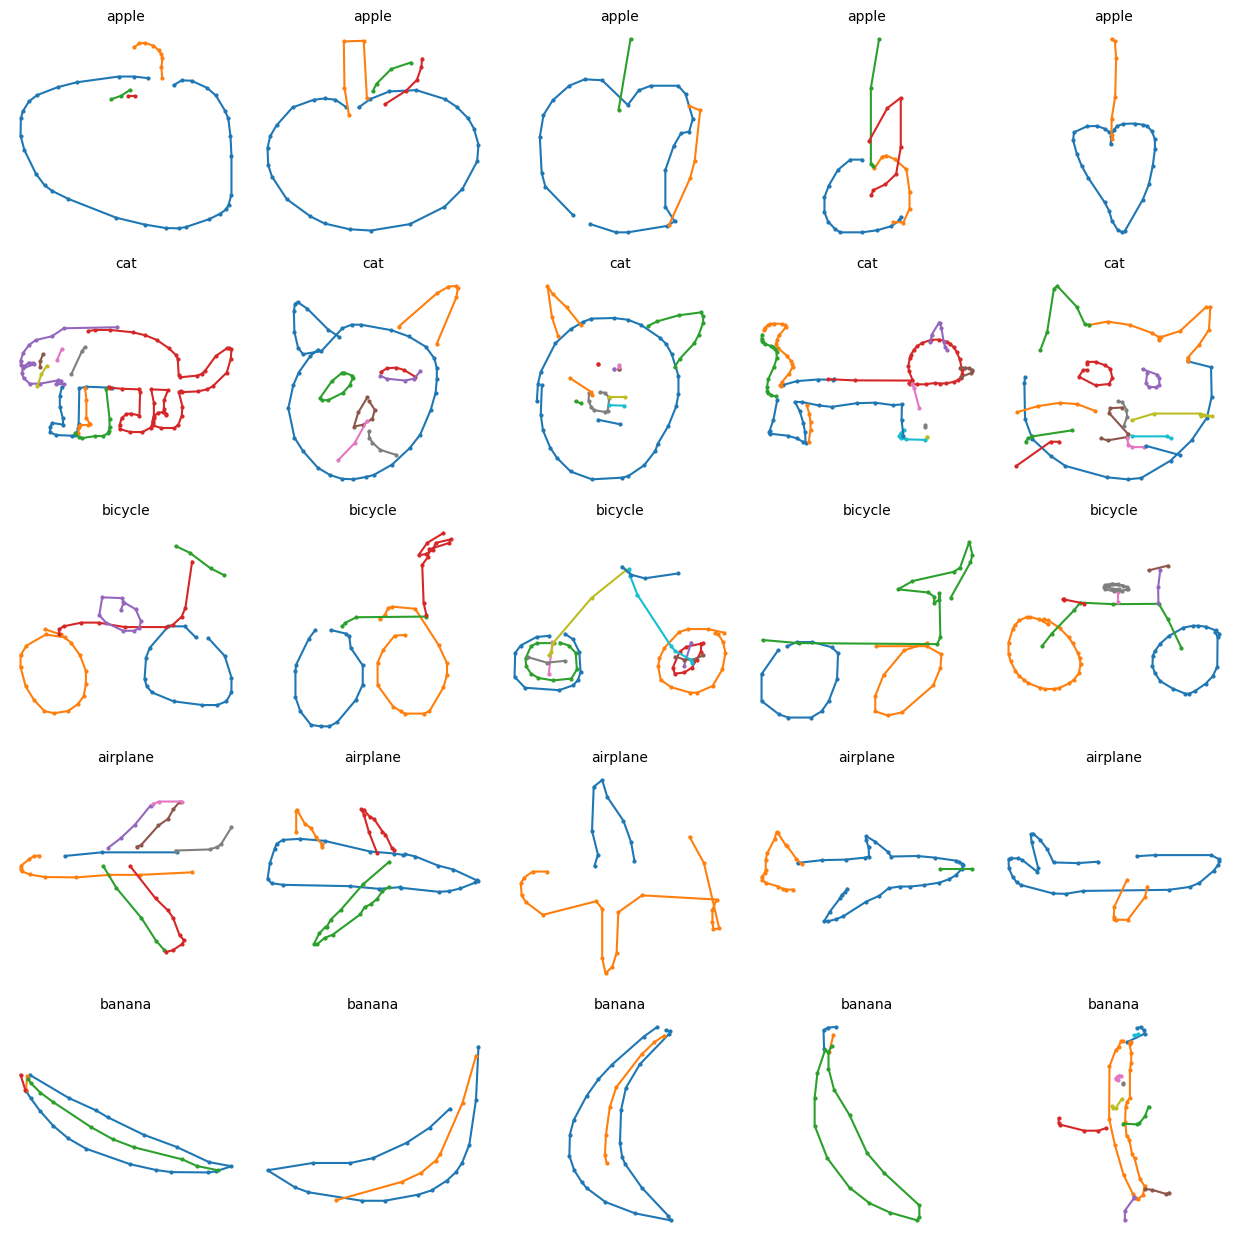

In [5]:
num_rows = len(classes)
num_cols = 5

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 2.5))

for row_idx, category in enumerate(classes):
    # Randomly sample instances from the training set of the given class
    indices = np.random.choice(len(data[category]['train']), size=num_cols, replace=False)
    
    for col_idx, sample_idx in enumerate(indices):
        ax = axes[row_idx, col_idx]
        sketch_data = data[category]['train'][sample_idx]
        plot_sketch(sketch_data, ax=ax, title=category)

plt.tight_layout()
plt.show()

### **Preprocessing Data**

**Normalize \(dx\) and \(dy\) to a standard normal distribution with zero mean and unit variance.**

In [6]:
# Collect all (dx, dy) values from the training set
train_coords = []
for category in classes:
    for sketch in data[category]['train']:
        train_coords.append(sketch[:, :2])

# Combine all (dx, dy) values into a single 2D array with shape (total points, 2)
train_coords = np.vstack(train_coords).astype(np.float32) # float32 is required for continuous normalization (mean/std)

# Calculate mean and standard deviation
mean_dx, mean_dy = np.mean(train_coords, axis=0)
std_dx, std_dy = np.std(train_coords, axis=0)

print(f"Mean: dx = {mean_dx:.4f}, dy = {mean_dy:.4f}")
print(f"Std: dx = {std_dx:.4f}, dy = {std_dy:.4f}")

Mean: dx = 1.3422, dy = 0.0380
Std: dx = 52.8871, dy = 34.0733


Normalize dx, dy

In [7]:
def normalize_sketch(sketch):
    norm_sketch = sketch.astype(np.float32).copy()
    norm_sketch[:, 0] = (norm_sketch[:, 0] - mean_dx) / std_dx
    norm_sketch[:, 1] = (norm_sketch[:, 1] - mean_dy) / std_dy
    return norm_sketch

Apply the normalization to the train, validation, and test sets across all classes.

In [8]:
norm_data = {}
for category in classes:
    norm_data[category] = {}
    for split in ['train', 'valid', 'test']:
        norm_data[category][split] = [
            normalize_sketch(sketch) for sketch in data[category][split]
        ]

Verify the mean and standard deviation of the training set after normalization.

In [9]:
sample_norm_coords = np.vstack([
    sketch[:, :2] for category in classes for sketch in norm_data[category]['train']
])

print(f"Mean: dx = {np.mean(sample_norm_coords[:, 0]):.4f}, dy = {np.mean(sample_norm_coords[:, 1]):.4f}")
print(f"Std : dx = {np.std(sample_norm_coords[:, 0]):.4f}, dy = {np.std(sample_norm_coords[:, 1]):.4f}")

Mean: dx = 0.0000, dy = 0.0000
Std : dx = 1.0199, dy = 1.0203


**Merge Class Data and Label Encoding**

In [10]:
# Create a mapping dictionary: class name → integer
label_map = {category: idx for idx, category in enumerate(classes)}
label_map

{'apple': 0, 'cat': 1, 'bicycle': 2, 'airplane': 3, 'banana': 4}

Collect the sketches and assign corresponding labels to each dataset split.

In [11]:
def collect_data(split_type):
    X = []
    y = []
    for category in classes:
        for sketch in norm_data[category][split_type]:
            X.append(sketch)
            y.append(label_map[category])
    return X, np.array(y, dtype=np.int64) # Cast to int64 for direct compatibility with PyTorch loss functions (which require torch.long)

In [12]:
X_train_raw, y_train = collect_data('train')
X_valid_raw, y_valid = collect_data('valid')
X_test_raw,  y_test  = collect_data('test')

print(f"Number of sketches in each dataset:")
print(f"- Train : {len(y_train)} sketches")
print(f"- Valid : {len(y_valid)} sketches")
print(f"- Test  : {len(y_test)} sketches")

Number of sketches in each dataset:
- Train : 350000 sketches
- Valid : 12500 sketches
- Test  : 12500 sketches


In [13]:
print("Label distribution in the training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"- Class {u} ({classes[u]}): {c} sketches")

Label distribution in the training set:
- Class 0 (apple): 70000 sketches
- Class 1 (cat): 70000 sketches
- Class 2 (bicycle): 70000 sketches
- Class 3 (airplane): 70000 sketches
- Class 4 (banana): 70000 sketches


**Strokes Padding**

In [14]:
def pad_strokes(X_raw, max_len=130):
    num_samples = len(X_raw)

    # Initialize an array of zeros with shape (number of samples, max_len, 3)
    X_padded = np.zeros((num_samples, max_len, 3), dtype=np.float32) # Same dtype as dx, dy
    # Store true sequence lengths so RNN can ignore zero-padding
    seq_lengths = np.zeros(num_samples, dtype=np.int64) # Needed for Pytorch functions

    for i, sketch in enumerate(X_raw):
        length = len(sketch)

        # Limit length at max_len
        actual_len = min(length, max_len)
        seq_lengths[i] = actual_len

        # Assign the sketch to the padded array
        X_padded[i, :actual_len, :] = sketch[:actual_len]

    return X_padded, seq_lengths

In [15]:
X_train, len_train = pad_strokes(X_train_raw)
X_valid, len_valid = pad_strokes(X_valid_raw)
X_test,  len_test  = pad_strokes(X_test_raw)

print("Shapes after Padding:")
print(f"- X_train: {X_train.shape}, len_train: {len_train.shape}")
print(f"- X_valid: {X_valid.shape}, len_valid: {len_valid.shape}")
print(f"- X_test : {X_test.shape}, len_test : {len_test.shape}")

Shapes after Padding:
- X_train: (350000, 130, 3), len_train: (350000,)
- X_valid: (12500, 130, 3), len_valid: (12500,)
- X_test : (12500, 130, 3), len_test : (12500,)


**Create Datasets**

Set the seed to ensure reproducibility

In [16]:
import torch
import random

SEED = 42

def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

Convert Data to TensorDataset

In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(len_train),
    torch.tensor(y_train)
)

valid_dataset = TensorDataset(
    torch.tensor(X_valid),
    torch.tensor(len_valid),
    torch.tensor(y_valid)
)

test_dataset = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(len_test),
    torch.tensor(y_test)
)

Create Dataloaders

In [18]:
BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # shuffle = true helps model sees different samples per batch during training
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches per epoch:")
print(f"- Train: {len(train_loader)} batches")
print(f"- Valid: {len(valid_loader)} batches")
print(f"- Test : {len(test_loader)} batches")

Number of batches per epoch:
- Train: 171 batches
- Valid: 7 batches
- Test : 7 batches


In [19]:
sample_x, sample_len, sample_y = next(iter(train_loader))
print("Checking the information of one sample batch:")
print(f"- Feature batch shape (batch_size, seq_len, features): {sample_x.shape}")
print(f"- Lengths batch shape: {sample_len.shape}")
print(f"- Labels batch shape : {sample_y.shape}")

Checking the information of one sample batch:
- Feature batch shape (batch_size, seq_len, features): torch.Size([2048, 130, 3])
- Lengths batch shape: torch.Size([2048])
- Labels batch shape : torch.Size([2048])


### **Building RNN Model**

In [20]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    # input_size: number of features at each time step
    # hidden_size: number of hidden state dimensions
    # num_layers: number of stacked RNN layers
    # num_classes: number of output classes
    def __init__(self, input_size=3, hidden_size=64, num_layers=1, num_classes=len(classes)):
        super(RNNClassifier, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        
        # Fully Connected Layer for classifying
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        # Pack the sequences so the RNN ignores padded time steps
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # Pass the packed sequences through the RNN
        # h_n shape: (num_layers, batch_size, hidden_size)
        _, h_n = self.rnn(packed_x)
        
        # Get the hidden state from the last (top) RNN layer
        last_hidden = h_n[-1]  # shape: (batch_size, hidden_size)
        
        # Classification
        out = self.fc(last_hidden)  # shape: (batch_size, num_classes)
        return out

In [21]:
set_seed()

# Choose device (cpu/gpu)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNClassifier().to(device)

print(f"Device used: {device}")
print(model)

# Run one batch to test the forward pass
test_out = model(sample_x.to(device), sample_len)
print(f"Checking forward pass:")
print(f"- Input batch shape : {sample_x.shape}")
print(f"- Output logits shape: {test_out.shape} (expected: [{BATCH_SIZE}, {len(classes)}])")

Device used: cuda
RNNClassifier(
  (rnn): RNN(3, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)
Checking forward pass:
- Input batch shape : torch.Size([2048, 130, 3])
- Output logits shape: torch.Size([2048, 5]) (expected: [2048, 5])


Loss function

In [22]:
criterion = nn.CrossEntropyLoss() # use cross entropy loss because there are 5 classes to classify

# Check the loss calculation on the sample batch
sample_loss = criterion(test_out, sample_y.to(device))

print("Loss function:", criterion)
print(f"Initial loss on the first batch: {sample_loss.item():.4f}")
print(f"Theoretical initial expectation: -ln(1/5) = ln(5) ≈ {np.log(5):.4f}")

Loss function: CrossEntropyLoss()
Initial loss on the first batch: 1.6154
Theoretical initial expectation: -ln(1/5) = ln(5) ≈ 1.6094


Optimizer

In [23]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=1e-1)

# Count the total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Selected optimizer:", optimizer.__class__.__name__)
print(f"Learning rate      : {optimizer.param_groups[0]['lr']}")
print(f"Total parameters   : {total_params:,} parameters")

# Print details of the parameter groups (RNN weights and FC weights)
print("Details of trainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"- {name:20s}: shape {tuple(param.shape)}")

Selected optimizer: SGD
Learning rate      : 0.1
Total parameters   : 4,741 parameters
Details of trainable parameters:
- rnn.weight_ih_l0    : shape (64, 3)
- rnn.weight_hh_l0    : shape (64, 64)
- rnn.bias_ih_l0      : shape (64,)
- rnn.bias_hh_l0      : shape (64,)
- fc.weight           : shape (5, 64)
- fc.bias             : shape (5,)


### **Training RNN Model**

In [24]:
from tqdm.auto import tqdm
import time

EPOCHS = 10

def get_grad_norm(model):
    # Compute the L2 norm of the gradients across the entire model
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

def train_model(model, train_loader):
    # Save train, val, gradient norms history of each batch for plotting graph
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'grad_norms': []
    }

    print(f"Starting training for {EPOCHS} epochs on {device}...")
    print("-" * 65)

    for epoch in range(EPOCHS):
        start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        # Progress bar for training loop
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS:02d} [Train]", leave=False)
        
        for x_batch, len_batch, y_batch in train_pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Reset gradients to prevent accumulation from the previous batch
            optimizer.zero_grad()

            outputs = model(x_batch, len_batch)
            loss = criterion(outputs, y_batch)

            # Update train correct
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == y_batch).sum().item()

            # Compute gradients of the loss with respect to model parameters
            loss.backward()
            
            # Compute and record the gradient norm of the current batch
            grad_norm = get_grad_norm(model)
            history['grad_norms'].append(grad_norm)
            
            # Update model parameters
            optimizer.step()
            
            # Update train loss and train total
            train_loss += loss.item() * x_batch.size(0)
            train_total += x_batch.size(0)
            
            # Update the progress bar with current loss and gradient norm
            train_pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'grad_norm': f"{grad_norm:.4f}"
            })
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        # Progress bar for validation loop
        val_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS:02d} [Val]", leave=False)
        
        # Disable gradients to speed up validation and reduce ram usage
        with torch.no_grad():
            for x_batch, len_batch, y_batch in val_pbar:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                
                outputs = model(x_batch, len_batch)
                loss = criterion(outputs, y_batch)
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y_batch).sum().item()

                val_loss += loss.item() * x_batch.size(0)
                val_total += x_batch.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({elapsed:.1f}s) | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc*100:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc*100:.2f}%")

    print("-" * 65)
    print("Training complete!")

    return history

history = train_model(model, train_loader)

Starting training for 10 epochs on cuda...
-----------------------------------------------------------------


Epoch 01/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 01/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [01/10] (5.2s) | Train Loss: 1.5990 | Train Acc: 25.37% | Val Loss: 1.5573 | Val Acc: 33.59%


Epoch 02/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

...

Epoch 09/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [09/10] (5.7s) | Train Loss: 1.5752 | Train Acc: 27.91% | Val Loss: 1.4560 | Val Acc: 38.06%


Epoch 10/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [10/10] (5.7s) | Train Loss: 1.4374 | Train Acc: 39.36% | Val Loss: 1.3375 | Val Acc: 44.22%
-----------------------------------------------------------------
Training complete!


### **Plotting training graph**

Plotting train and validation loss, train and validation accuracy

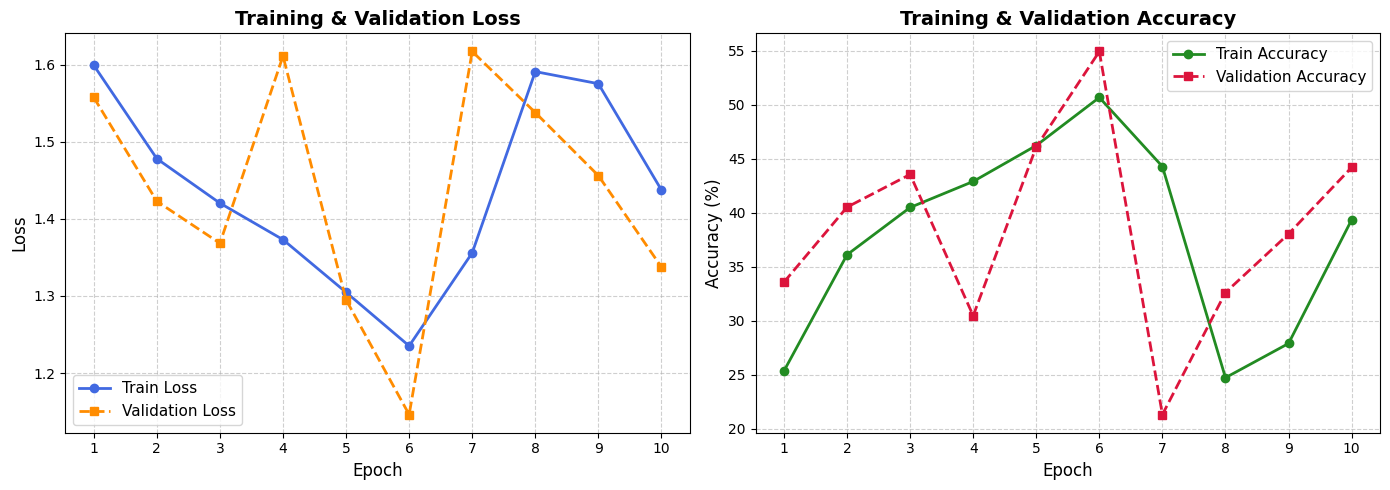

In [25]:
import matplotlib.pyplot as plt

def plot_graph_loss_acc(history):
    epochs = range(1, EPOCHS + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Training & Validation Loss
    axes[0].plot(epochs, history['train_loss'], marker='o', color='royalblue', linewidth=2, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], marker='s', linestyle='--', color='darkorange', linewidth=2, label='Validation Loss')
    axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_xticks(list(epochs))
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(fontsize=11)

    # Plot Training & Validation Accuracy
    train_acc_pct = [acc * 100 for acc in history['train_acc']]
    val_acc_pct = [acc * 100 for acc in history['val_acc']]

    axes[1].plot(epochs, train_acc_pct, marker='o', color='forestgreen', linewidth=2, label='Train Accuracy')
    axes[1].plot(epochs, val_acc_pct, marker='s', linestyle='--', color='crimson', linewidth=2, label='Validation Accuracy')
    axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_xticks(list(epochs))
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.show()

plot_graph_loss_acc(history)

Plotting gradient norms graph

Gradient Norm Statistics:
- Max gradient norm   : 17.1490
- Min gradient norm   : 0.036271
- Mean gradient norm  : 1.1050
- Median gradient norm: 0.8750


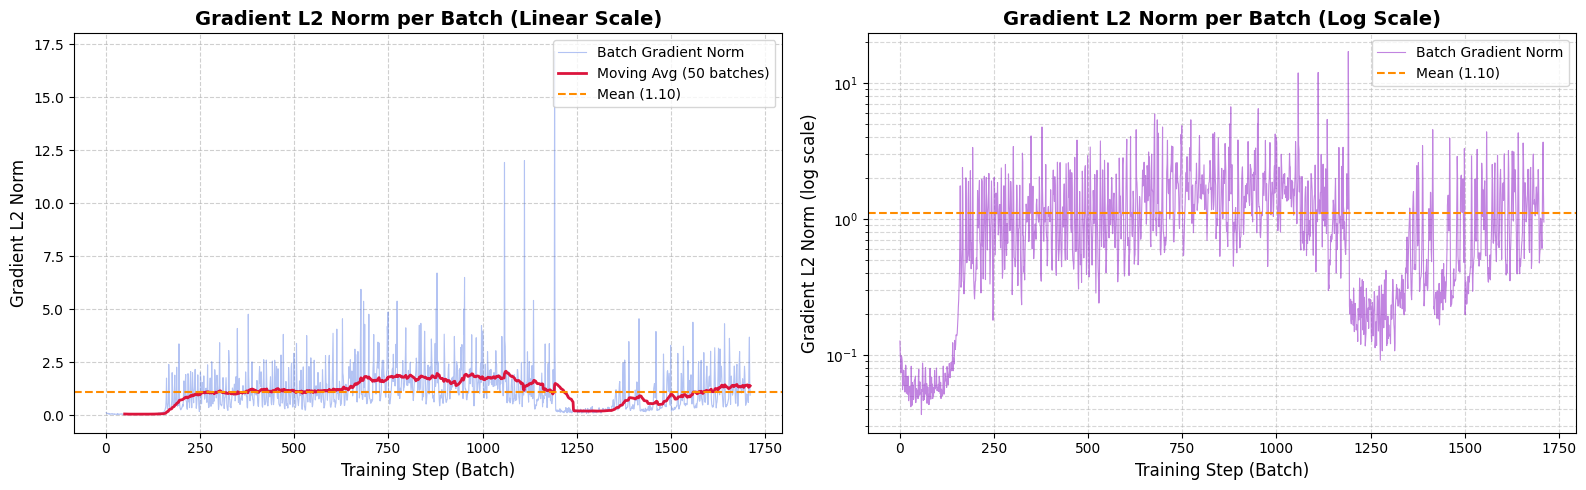

In [26]:
def plot_graph_grad(history):
    grad_norms = history['grad_norms']
    steps = np.arange(1, len(grad_norms) + 1)

    # Summary statistics of gradient norms
    print("Gradient Norm Statistics:")
    print(f"- Max gradient norm   : {np.max(grad_norms):.4f}")
    print(f"- Min gradient norm   : {np.min(grad_norms):.6f}")
    print(f"- Mean gradient norm  : {np.mean(grad_norms):.4f}")
    print(f"- Median gradient norm: {np.median(grad_norms):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot Gradient Norm on Linear Scale
    axes[0].plot(steps, grad_norms, color='royalblue', alpha=0.4, linewidth=0.8, label='Batch Gradient Norm')

    # Moving average to smooth out batch-level fluctuations
    window_size = 50
    if len(grad_norms) >= window_size:
        moving_avg = np.convolve(grad_norms, np.ones(window_size) / window_size, mode='valid')
        axes[0].plot(
            range(window_size, len(grad_norms) + 1),
            moving_avg,
            color='crimson',
            linewidth=2,
            label=f'Moving Avg ({window_size} batches)'
        )

    axes[0].axhline(y=np.mean(grad_norms), color='darkorange', linestyle='--', linewidth=1.5, label=f'Mean ({np.mean(grad_norms):.2f})')
    axes[0].set_title('Gradient L2 Norm per Batch (Linear Scale)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Training Step (Batch)', fontsize=12)
    axes[0].set_ylabel('Gradient L2 Norm', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(loc='upper right', fontsize=10)

    # Plot Gradient Norm on Logarithmic Scale
    axes[1].plot(steps, grad_norms, color='darkorchid', alpha=0.6, linewidth=0.8, label='Batch Gradient Norm')
    axes[1].set_yscale('log')
    axes[1].axhline(y=np.mean(grad_norms), color='darkorange', linestyle='--', linewidth=1.5, label=f'Mean ({np.mean(grad_norms):.2f})')
    axes[1].set_title('Gradient L2 Norm per Batch (Log Scale)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Training Step (Batch)', fontsize=12)
    axes[1].set_ylabel('Gradient L2 Norm (log scale)', fontsize=12)
    axes[1].grid(True, which='both', linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_graph_grad(history)

**Evidence of Exploding Gradients**
* **Observations from the Graphs:**
  * **Gradient Spike:** Near step $\approx 1185$ (end of Epoch 7), gradient norm spikes to a peak of **$17.15$** (**$15.5\times$** the mean of $1.10$).
  * **Performance Collapse (Epochs 7–8):** Validation accuracy plummets from **$54.95\%$** (Epoch 6) to **$21.33\%$** (Epoch 7). Epoch 8 training accuracy drops to **$24.74\%$** (loss jumps to **$1.5909$**), while gradients collapse into a flat "dead zone" ($0.1–0.3$) due to activation saturation.
* **Why it occurred:** Backpropagation through long sequences (up to 130 steps) caused gradients to grow exponentially ($(\gamma \|W_{hh}\|)^t \gg 1$), destabilizing the weights and crippling model convergence.

### **Empirical Demonstration of Vanishing Gradients**

Although the empirical curves above do not distinctly exhibit the vanishing gradient phenomenon, we conduct a controlled simulation below to explicitly demonstrate its behavior.

In [27]:
class RNNClassifierVanishing(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_classes=5):
        super().__init__()
        self.hidden_size = hidden_size
        # Use nn.RNNCell instead of nn.RNN to process one step at a time, allowing explicit tracking of dL/dh_t at each time step
        self.rnn_cell = nn.RNNCell(input_size, hidden_size, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        batch_size, seq_len, _ = x.shape
        # Set the base hidden state (h_0 = 0) prior to temporal recurrence
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        hidden_states = []
        for t in range(seq_len):
            # Compute the current hidden state h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b)
            h = self.rnn_cell(x[:, t, :], h)
            # Instruct autograd to preserve dL/dh_t for non-leaf intermediate activations during backpropagation
            h.retain_grad()
            hidden_states.append(h)
            
        out = self.fc(hidden_states[-1])
        return hidden_states, out

Identify the sample with the maximum sequence length (129).

In [28]:
max_idx = int(np.argmax(len_train))
actual_max_len = int(len_train[max_idx])

# Extract the sample and trim it to its actual sequence length, removing all trailing zero padding.
# Shape: (1, actual_max_len, 3) - batch_size = 1
sample_x_max = torch.tensor(
    X_train[max_idx : max_idx + 1, :actual_max_len, :], 
    dtype=torch.float32
)
sample_y_max = torch.tensor(
    y_train[max_idx : max_idx + 1], 
    dtype=torch.long
)

print("Longest sequence sample:")
print(f"- Training set index     : {max_idx}")
print(f"- Category               : {classes[sample_y_max.item()]} (label: {sample_y_max.item()})")
print(f"- Actual sequence length : {actual_max_len} steps (no zero padding)")
print(f"- sample_x_max shape     : {sample_x_max.shape}")
print(f"- sample_y_max shape     : {sample_y_max.shape}")

Longest sequence sample:
- Training set index     : 70642
- Category               : cat (label: 1)
- Actual sequence length : 129 steps (no zero padding)
- sample_x_max shape     : torch.Size([1, 129, 3])
- sample_y_max shape     : torch.Size([1])


Gradient Norm Statistics across time steps:
- Last step (t=128) : 0.562963
- First step (t=0)  : 0.000000e+00
- Decay factor      : ~562,962,591,648x reduction


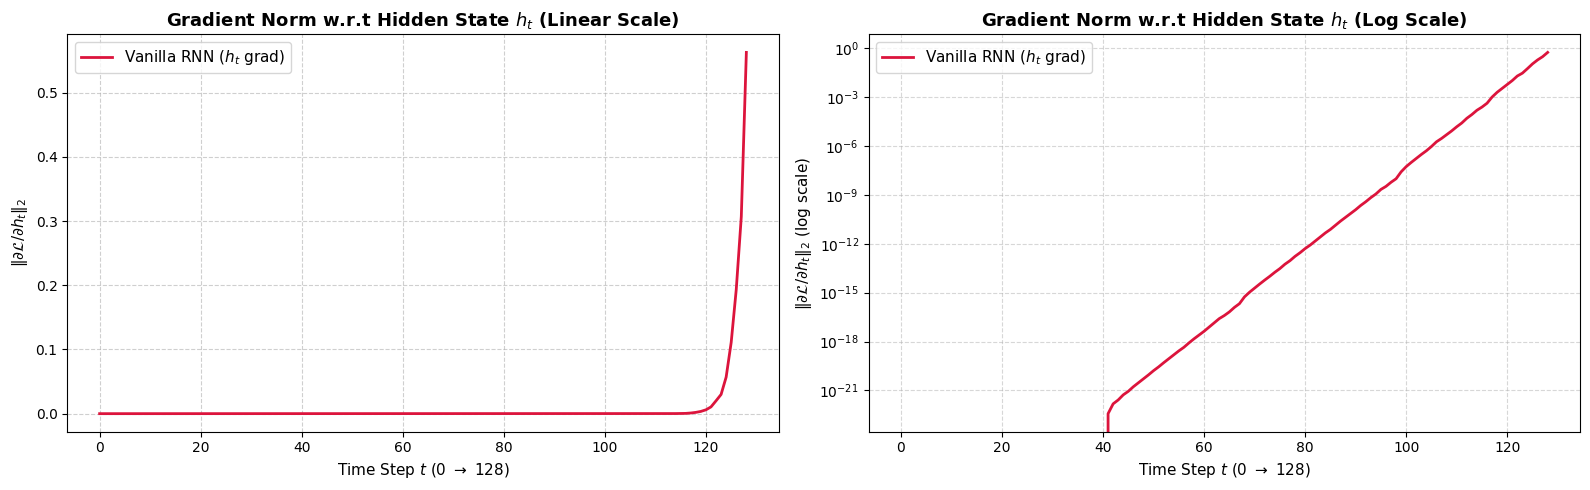

In [29]:
sim_model = RNNClassifierVanishing().to(device)

# Forward and backward pass
sim_model.zero_grad()
hidden_states, out = sim_model(sample_x_max.to(device))
loss = criterion(out, sample_y_max.to(device))
loss.backward()

# Extract ||dL / dh_t|| for each time step
grad_norms = [h_t.grad.norm(2).item() for h_t in hidden_states]

# Summary Statistics
seq_len = sample_x_max.size(1)
decay_ratio = grad_norms[-1] / max(grad_norms[0], 1e-12)
print("Gradient Norm Statistics across time steps:")
print(f"- Last step (t={seq_len-1}) : {grad_norms[-1]:.6f}")
print(f"- First step (t=0)  : {grad_norms[0]:.6e}")
print(f"- Decay factor      : ~{decay_ratio:,.0f}x reduction")

# Plot Gradient Vanishing Curves (Linear & Log Scale)
time_steps = np.arange(seq_len)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear Scale Plot
axes[0].plot(time_steps, grad_norms, color='crimson', linewidth=2, label='Vanilla RNN ($h_t$ grad)')
axes[0].set_title('Gradient Norm w.r.t Hidden State $h_t$ (Linear Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'Time Step $t$ (0 $\\rightarrow$ {seq_len - 1})', fontsize=11)
axes[0].set_ylabel('$\\|\\partial \\mathcal{L} / \\partial h_t\\|_2$', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=11)

# Logarithmic Scale Plot (highlights the exponential decay)
axes[1].plot(time_steps, grad_norms, color='crimson', linewidth=2, label='Vanilla RNN ($h_t$ grad)')
axes[1].set_yscale('log')
axes[1].set_title('Gradient Norm w.r.t Hidden State $h_t$ (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'Time Step $t$ (0 $\\rightarrow$ {seq_len - 1})', fontsize=11)
axes[1].set_ylabel('$\\|\\partial \\mathcal{L} / \\partial h_t\\|_2$ (log scale)', fontsize=11)
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Evidence of Vanishing Gradients**
* **Observations from the Graphs:**
  * **Exponential Decay:** The log-scale plot demonstrates a relentless, linear-in-log drop: the gradient norm falls from **$0.562963$** at the final step ($t=128$) down to under **$10^{-12}$** by $t \approx 80$, drops below **$10^{-20}$** by $t \approx 45$, and completely underflows to **$0.0$** (machine precision limit) by **$t \approx 41$**. This represents a staggering decay factor of over **$562.9\text{ billion times}$** ($\approx 5.63 \times 10^{11}\times$).
  * **Temporal Amnesia:** On the linear scale, the gradient magnitude is imperceptible and flatlined at zero for over **$93\%$** of the sequence ($t=0 \rightarrow 120$). The network assigns credit and learns almost exclusively from the last $\approx 8$ strokes ($t=121 \rightarrow 128$), completely blind to the foundational strokes at the beginning of the drawing.
* **Why it occurred:** Due to repeated Jacobian multiplications across 129 genuine stroke steps where $|\tanh'| \le 1$ and $\|W_{hh}\| < 1$, gradients attenuate exponentially $(\gamma \|W_{hh}\|)^{T-t} \to 0$. Without padding zeros masking the dynamics, the empirical test confirms that vanilla RNNs suffer catastrophic vanishing gradient over real sequential data of length $> 40$.

### **Solution to Gradient Exploding & Vanishing**

#### **Gradient Exploding**


##### **Method 1: Reducing the Learning Rate**

* **Mechanism:**
  In standard gradient descent:
  $$\mathbf{W}_{new} = \mathbf{W}_{old} - \eta \cdot \nabla_{\mathbf{W}} \mathcal{L}$$
  The effective parameter update magnitude $\|\Delta \mathbf{W}\|$ scales directly with the learning rate $\eta$. By lowering $\eta$ (e.g., from $0.1$ down to $0.01$ or $0.001$), the actual parameter step size is shrunk proportionally, which mitigates catastrophic destabilization when gradient spikes occur.

* **Advantages:**
  * Straightforward to implement; requires only tuning a single hyperparameter without altering the computation graph or gradients.

* **Limitations:**
  * **Slower Convergence:** A uniformly smaller learning rate substantially decelerates the optimization process across all steps.
  * **Does Not Fix the Root Cause:** Lowering $\eta$ scales down the update step, but does not prevent the gradients themselves from exponentially blowing up during BPTT ($(\gamma \|W_{hh}\|)^T \to \infty$). In very long sequences, numerical overflow (`Inf`/`NaN`) can still occur.

In [30]:
set_seed()

model_low_lr = RNNClassifier().to(device)
optimizer = optim.SGD(model_low_lr.parameters(), lr=5e-3) # decreased learning rate to 5e-3

low_lr_history = train_model(model_low_lr, train_loader)

Starting training for 10 epochs on cuda...
-----------------------------------------------------------------


Epoch 01/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 01/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [01/10] (5.8s) | Train Loss: 1.6134 | Train Acc: 19.23% | Val Loss: 1.6104 | Val Acc: 18.95%


Epoch 02/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

...

Epoch 09/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [09/10] (5.6s) | Train Loss: 1.6029 | Train Acc: 25.23% | Val Loss: 1.6021 | Val Acc: 25.51%


Epoch 10/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [10/10] (5.9s) | Train Loss: 1.6021 | Train Acc: 25.46% | Val Loss: 1.6014 | Val Acc: 25.92%
-----------------------------------------------------------------
Training complete!


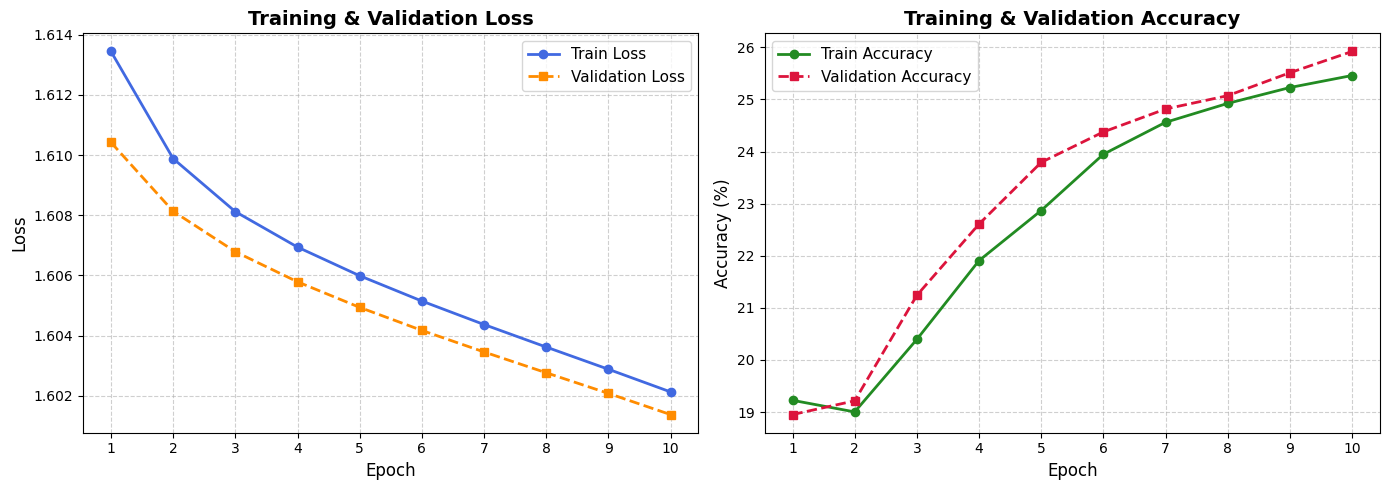

In [31]:
plot_graph_loss_acc(low_lr_history)

Gradient Norm Statistics:
- Max gradient norm   : 0.1352
- Min gradient norm   : 0.032903
- Mean gradient norm  : 0.0603
- Median gradient norm: 0.0575


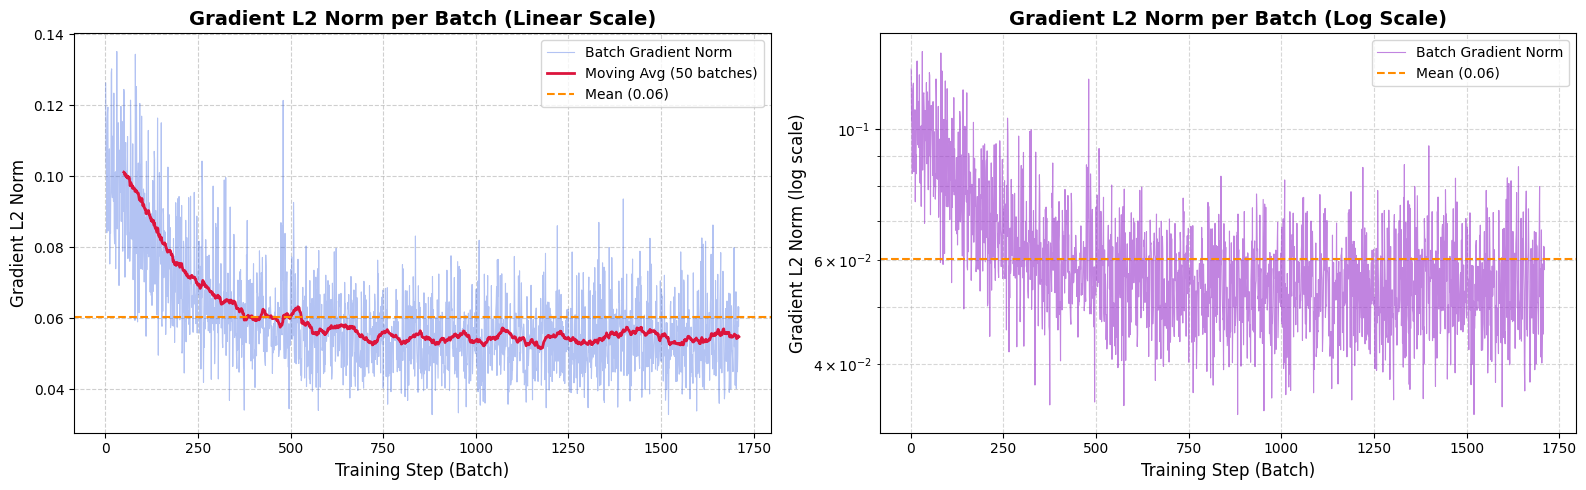

In [32]:
plot_graph_grad(low_lr_history)

**Case Gradients Explode even after reducing learning rate**


In [33]:
set_seed()

model_low_lr_explode = RNNClassifier().to(device)
optimizer = optim.SGD(model_low_lr_explode.parameters(), lr=5e-2) # decreased learning rate to 5e-2 (caused gradients explode)

low_lr_explode_history = train_model(model_low_lr_explode, train_loader)

Starting training for 10 epochs on cuda...
-----------------------------------------------------------------


Epoch 01/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 01/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [01/10] (5.8s) | Train Loss: 1.6063 | Train Acc: 22.80% | Val Loss: 1.6014 | Val Acc: 25.81%


Epoch 02/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

...

Epoch 09/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [09/10] (5.7s) | Train Loss: 1.2664 | Train Acc: 48.02% | Val Loss: 1.4523 | Val Acc: 37.34%


Epoch 10/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [10/10] (5.7s) | Train Loss: 1.4209 | Train Acc: 40.21% | Val Loss: 1.3625 | Val Acc: 42.71%
-----------------------------------------------------------------
Training complete!


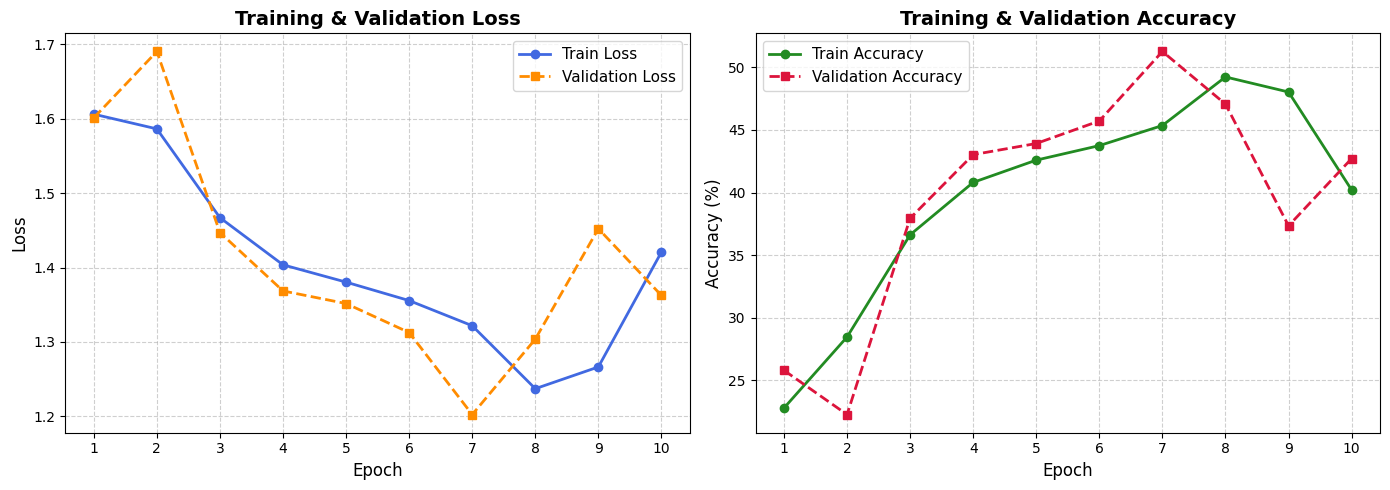

In [34]:
plot_graph_loss_acc(low_lr_explode_history)

Gradient Norm Statistics:
- Max gradient norm   : 41.3021
- Min gradient norm   : 0.037307
- Mean gradient norm  : 1.4434
- Median gradient norm: 1.2290


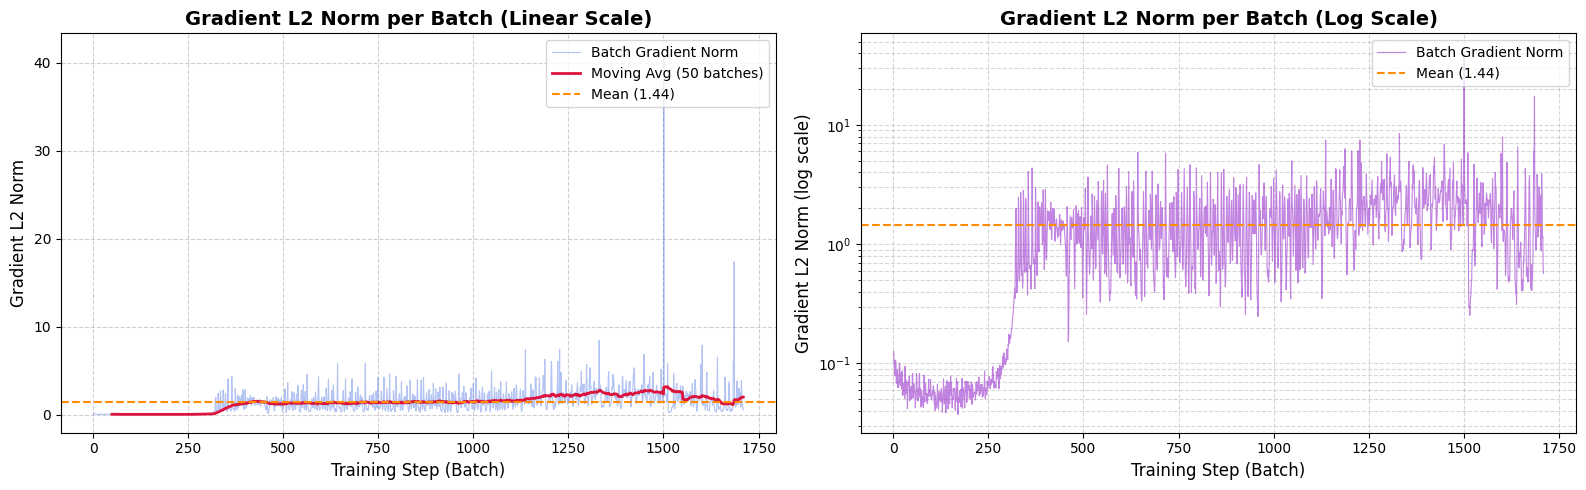

In [35]:
plot_graph_grad(low_lr_explode_history)

##### **Method 2: Gradient Clipping**

* **Mechanism:**
  Gradient clipping is a heuristic technique introduced by Pascanu et al. (2013) to cap the maximum magnitude of gradients before updating model parameters. Instead of reducing the global learning rate, it only intervenes when a gradient exceeds a predefined threshold $\theta$ (`max_norm`).

  The most widely used formulation is **L2 Norm Clipping**, which rescales the global gradient vector $\mathbf{g} = \nabla_{\mathbf{W}} \mathcal{L}$ across all model parameters:
  $$\mathbf{g} \leftarrow \begin{cases} \mathbf{g} & \text{if } \|\mathbf{g}\|_2 \le \theta \\ \frac{\theta}{\|\mathbf{g}\|_2} \mathbf{g} & \text{if } \|\mathbf{g}\|_2 > \theta \end{cases}$$

  * **Key Insight:** When $\|\mathbf{g}\|_2 > \theta$, the gradient vector is scaled down to have exactly norm $\theta$. Because every parameter's gradient is multiplied by the same scalar factor $\frac{\theta}{\|\mathbf{g}\|_2}$, the **direction of the gradient vector is strictly preserved**, changing only the step magnitude.

* **Advantages:**
  * **Directly Bounds Exploding Updates:** Guarantees that parameter updates remain bounded by $\eta \cdot \theta$, effectively taming catastrophic spikes near steep cliff-like loss surfaces common in RNNs.
  * **Maintains Fast Convergence:** Unlike simply shrinking the learning rate everywhere, gradient clipping allows using a high learning rate (e.g., $\eta = 0.1$) on well-behaved regions while acting as a safety net only during extreme spikes.
  * **Direction Preserving:** Unlike *value clipping* (which clips each gradient element independently and alters the update angle), *norm clipping* maintains the true descent trajectory.

* **Limitations:**
  * **Hyperparameter Sensitivity:** Introduces an additional hyperparameter $\theta$ (`max_norm`), which usually requires tuning (typical values range from $0.5$ to $5.0$).
  * **Asymmetric Solution:** Gradient clipping **only resolves exploding gradients**; it provides zero remedy for the vanishing gradient problem, where gradients decay exponentially toward zero ($(\gamma \|W_{hh}\|)^{T-t} \to 0$).

In [36]:
set_seed()

model_grad_clip = RNNClassifier().to(device)
optimizer = optim.SGD(model_grad_clip.parameters(), lr=1e-1)

Train model with gradients clipping to 4.0

In [37]:
def train_model_with_grad_clip(model, train_loader, max_grad=4.0):
    # Save train, val, gradient norms history of each batch for plotting graph
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'grad_norms': []
    }

    print(f"Starting training for {EPOCHS} epochs on {device}...")
    print("-" * 65)

    for epoch in range(EPOCHS):
        start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        # Progress bar for training loop
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS:02d} [Train]", leave=False)
        
        for x_batch, len_batch, y_batch in train_pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Reset gradients to prevent accumulation from the previous batch
            optimizer.zero_grad()

            outputs = model(x_batch, len_batch)
            loss = criterion(outputs, y_batch)

            # Update train correct
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == y_batch).sum().item()

            # Compute gradients of the loss with respect to model parameters
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad)
            
            # Compute and record the gradient norm of the current batch
            grad_norm = get_grad_norm(model)
            history['grad_norms'].append(grad_norm)
            
            # Update model parameters
            optimizer.step()
            
            # Update train loss and train total
            train_loss += loss.item() * x_batch.size(0)
            train_total += x_batch.size(0)
            
            # Update the progress bar with current loss and gradient norm
            train_pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'grad_norm': f"{grad_norm:.4f}"
            })
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        # Progress bar for validation loop
        val_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS:02d} [Val]", leave=False)
        
        # Disable gradients to speed up validation and reduce ram usage
        with torch.no_grad():
            for x_batch, len_batch, y_batch in val_pbar:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                
                outputs = model(x_batch, len_batch)
                loss = criterion(outputs, y_batch)
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y_batch).sum().item()

                val_loss += loss.item() * x_batch.size(0)
                val_total += x_batch.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({elapsed:.1f}s) | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc*100:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc*100:.2f}%")

    print("-" * 65)
    print("Training complete!")

    return history

history_grad_clip = train_model_with_grad_clip(model_grad_clip, train_loader)

Starting training for 10 epochs on cuda...
-----------------------------------------------------------------


Epoch 01/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 01/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [01/10] (5.6s) | Train Loss: 1.5990 | Train Acc: 25.37% | Val Loss: 1.5573 | Val Acc: 33.59%


Epoch 02/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

...

Epoch 09/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [09/10] (5.7s) | Train Loss: 1.0716 | Train Acc: 59.24% | Val Loss: 1.7538 | Val Acc: 34.42%


Epoch 10/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [10/10] (5.7s) | Train Loss: 1.0493 | Train Acc: 60.54% | Val Loss: 0.9503 | Val Acc: 63.99%
-----------------------------------------------------------------
Training complete!


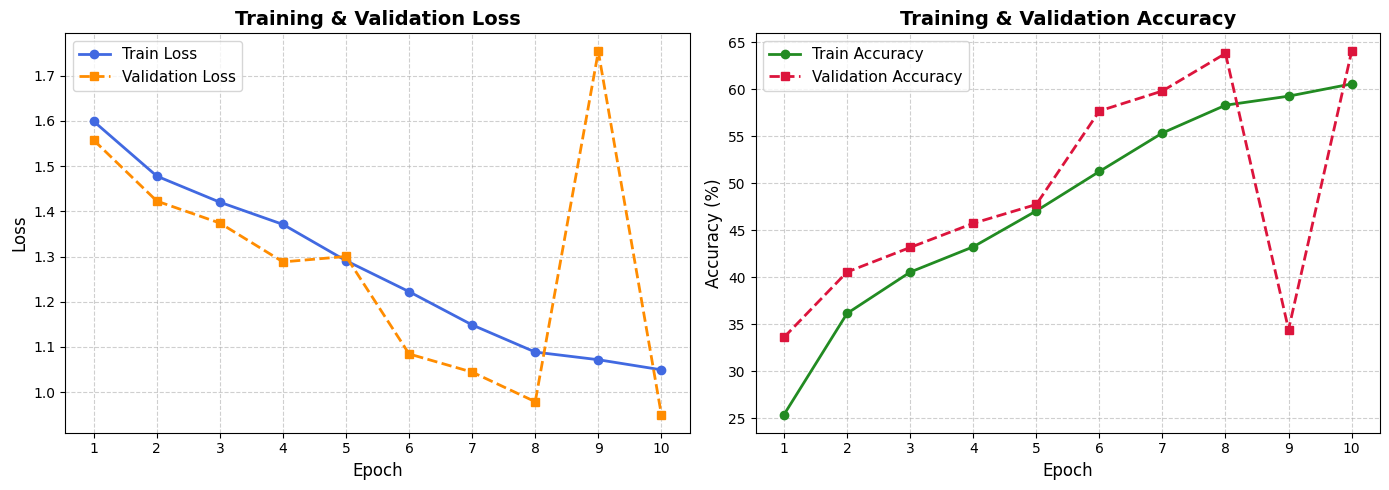

In [38]:
plot_graph_loss_acc(history_grad_clip)

Gradient Norm Statistics:
- Max gradient norm   : 4.0000
- Min gradient norm   : 0.036271
- Mean gradient norm  : 1.5501
- Median gradient norm: 1.3641


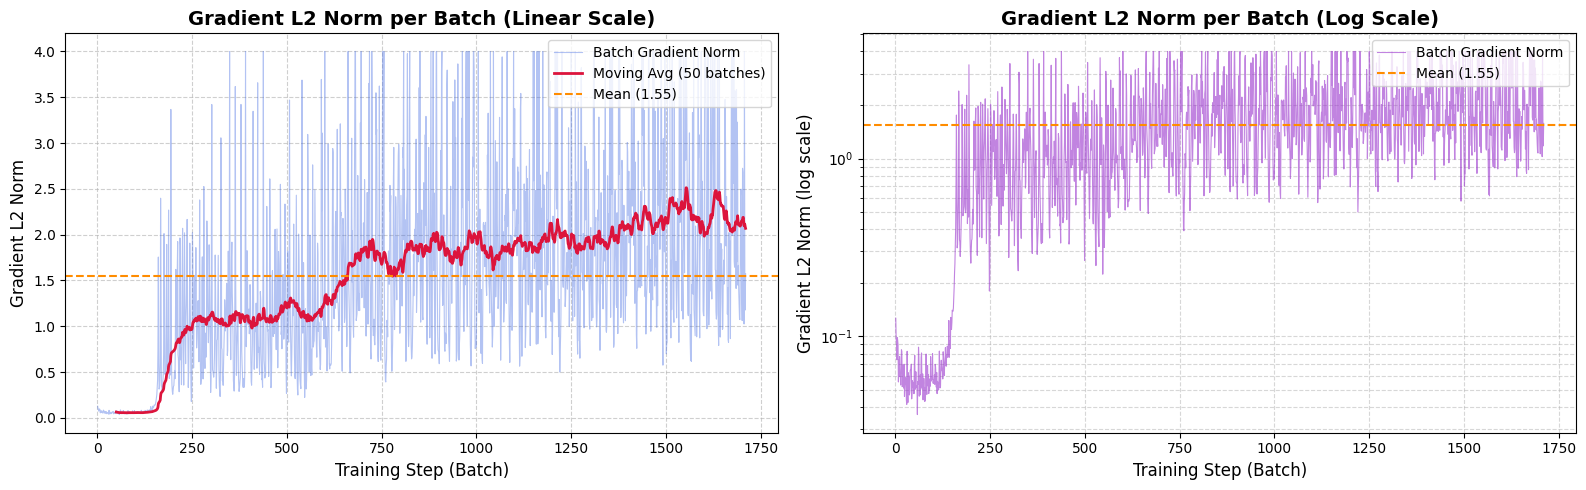

In [39]:
plot_graph_grad(history_grad_clip)

#### **Gradient Vanishing**

##### **Method 1: Gated Architecture — Long Short-Term Memory (LSTM)**

* **Mechanism:**
  Introduced by Hochreiter & Schmidhuber (1997), the **Long Short-Term Memory (LSTM)** network fundamentally resolves the vanishing gradient problem by redesigning the internal recurrent cell. 
  
  In a vanilla RNN, the temporal gradient relies on continuous multiplicative Jacobian chains:
  $$\frac{\partial \mathbf{h}_T}{\partial \mathbf{h}_t} = \prod_{k=t+1}^T \frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}} = \prod_{k=t+1}^T \operatorname{diag}\left(1 - \tanh^2(\cdot)\right) \mathbf{W}_{hh}^T$$
  When $|1 - \tanh^2(\cdot)| < 1$ or $\|\mathbf{W}_{hh}\| < 1$, the gradient decays exponentially to $0$ as $(T - t)$ increases.

  LSTM bypasses this problem by introducing a dedicated **Cell State ($\mathbf{c}_t$)** governed by an **additive update rule** via gating mechanisms:
  
  1. **Forget Gate ($\mathbf{f}_t$):** Controls what information to discard from the previous cell state:
     $$\mathbf{f}_t = \sigma(\mathbf{W}_f \mathbf{x}_t + \mathbf{U}_f \mathbf{h}_{t-1} + \mathbf{b}_f)$$
  2. **Input Gate ($\mathbf{i}_t$) & Candidate State ($\tilde{\mathbf{c}}_t$):** Determines what new information to store:
     $$\mathbf{i}_t = \sigma(\mathbf{W}_i \mathbf{x}_t + \mathbf{U}_i \mathbf{h}_{t-1} + \mathbf{b}_i)$$
     $$\tilde{\mathbf{c}}_t = \tanh(\mathbf{W}_c \mathbf{x}_t + \mathbf{U}_c \mathbf{h}_{t-1} + \mathbf{b}_c)$$
  3. **Cell State Update ($\mathbf{c}_t$):** Linear combination (additive update):
     $$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$
  4. **Output Gate ($\mathbf{o}_t$) & Hidden State ($\mathbf{h}_t$):** Decides the output based on the filtered cell state:
     $$\mathbf{o}_t = \sigma(\mathbf{W}_o \mathbf{x}_t + \mathbf{U}_o \mathbf{h}_{t-1} + \mathbf{b}_o)$$
     $$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

  * **Key Insight:** When backpropagating along the cell state path:
    $$\frac{\partial \mathbf{c}_t}{\partial \mathbf{c}_{t-1}} = \mathbf{f}_t$$
    Because the update to $\mathbf{c}_t$ is additive rather than purely multiplicative through a saturating non-linearity, the gradient highway allows error signals to flow backward across hundreds of time steps with virtually no decay, provided the forget gate remains active ($\mathbf{f}_t \approx 1$). This structure is known as the **Constant Error Carousel (CEC)**.

* **Advantages:**
  * **Eliminates Exponential Gradient Vanishing:** The linear cell state highway allows effective credit assignment to early time steps (e.g., initial sketch strokes at $t \approx 0$).
  * **Dynamic Long-Term Memory:** Gating mechanism enables the network to selectively remember, forget, or write features adaptively conditioned on input context.
  * **Superior Sequence Modeling:** Achieves markedly better convergence, stability, and classification accuracy compared to standard vanilla RNNs on sequences of length $\ge 100$.

* **Limitations:**
  * **Increased Computational & Memory Overhead:** An LSTM cell requires 4 internal linear projections ($\mathbf{f}, \mathbf{i}, \tilde{\mathbf{c}}, \mathbf{o}$), resulting in $\approx 4\times$ more parameters and floating-point operations per step than a vanilla RNN.
  * **Still Vulnerable to Exploding Gradients:** While LSTM resolves gradient vanishing along the cell state $\mathbf{c}$, the hidden state transitions and linear readout layers can still suffer from exploding gradients; it is standard practice to combine LSTMs with gradient clipping.
  * **Sequential Bottleneck:** Remains autoregressive along the temporal axis, preventing parallelization across time steps during training (unlike Transformers).

In [40]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_classes=5):
        super().__init__()
        self.hidden_size = hidden_size
        # Use nn.LSTMCell to process the sequence one time step at a time
        self.lstm_cell = nn.LSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

        # Initialize Forget Gate Bias to 2.0 to keep the CEC highway open
        with torch.no_grad():
            # In PyTorch's nn.LSTMCell, biases are concatenated into 4 gates: [i, f, g, o]
            # The slice [hidden_size : 2 * hidden_size] corresponds to the Forget Gate
            self.lstm_cell.bias_ih[hidden_size : 2 * hidden_size].fill_(2.0)
            self.lstm_cell.bias_hh[hidden_size : 2 * hidden_size].fill_(2.0)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        # Initialize base states: h_0 = 0, c_0 = 0
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        hidden_states = []
        cell_states = []
        
        for t in range(seq_len):
            # Compute (h_t, c_t) at time step t
            h, c = self.lstm_cell(x[:, t, :], (h, c))
            
            # Retain gradients for intermediate non-leaf activations during backprop
            h.retain_grad()
            c.retain_grad()
            
            hidden_states.append(h)
            cell_states.append(c)
            
        out = self.fc(hidden_states[-1])
        return hidden_states, cell_states, out

Gradient Norm Comparison (First Step t=0 vs Last Step t=128):
---------------------------------------------------------------------------
Vanilla RNN (h_t)      : t=128: 0.562963 | t=0: 0.000000e+00
LSTM (Cell State c_t)  : t=128: 0.000000 | t=0: 1.463658e+00
LSTM (Hidden State h_t): t=128: 0.531088 | t=0: 4.395734e-01
---------------------------------------------------------------------------


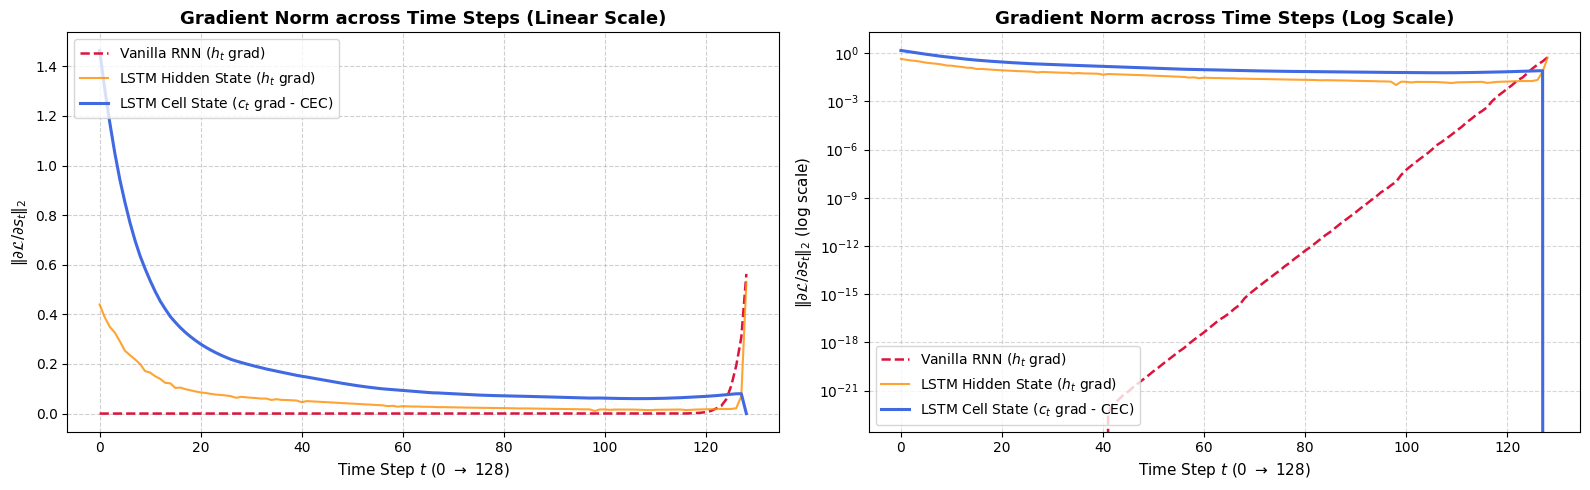

In [46]:
sim_lstm = LSTMClassifier().to(device)

# Forward and backward pass
sim_lstm.zero_grad()
lstm_h_states, lstm_c_states, lstm_out = sim_lstm(sample_x_max.to(device))
loss_lstm = criterion(lstm_out, sample_y_max.to(device))
loss_lstm.backward()

# Extract gradient norms: ||dL / dh_t|| and ||dL / dc_t||
lstm_h_grad_norms = [
    h.grad.norm(2).item() if h.grad is not None else 0.0 
    for h in lstm_h_states
]
lstm_c_grad_norms = [
    c.grad.norm(2).item() if c.grad is not None else 0.0 
    for c in lstm_c_states
]

# Summary statistics
seq_len = sample_x_max.size(1)
print(f"Gradient Norm Comparison (First Step t=0 vs Last Step t={seq_len-1}):")
print("-" * 75)
print(f"Vanilla RNN (h_t)      : t={seq_len-1}: {grad_norms[-1]:.6f} | t=0: {grad_norms[0]:.6e}")
print(f"LSTM (Cell State c_t)  : t={seq_len-1}: {lstm_c_grad_norms[-1]:.6f} | t=0: {lstm_c_grad_norms[0]:.6e}")
print(f"LSTM (Hidden State h_t): t={seq_len-1}: {lstm_h_grad_norms[-1]:.6f} | t=0: {lstm_h_grad_norms[0]:.6e}")
print("-" * 75)

# Plot Gradient Vanishing Curves (Linear & Log Scale)
time_steps = np.arange(seq_len)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear Scale Plot
axes[0].plot(time_steps, grad_norms, color='crimson', linewidth=1.8, linestyle='--', label='Vanilla RNN ($h_t$ grad)')
axes[0].plot(time_steps, lstm_h_grad_norms, color='darkorange', linewidth=1.5, alpha=0.8, label='LSTM Hidden State ($h_t$ grad)')
axes[0].plot(time_steps, lstm_c_grad_norms, color='royalblue', linewidth=2.2, label='LSTM Cell State ($c_t$ grad - CEC)')

axes[0].set_title('Gradient Norm across Time Steps (Linear Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'Time Step $t$ (0 $\\rightarrow$ {seq_len - 1})', fontsize=11)
axes[0].set_ylabel('$\\|\\partial \\mathcal{L} / \\partial s_t\\|_2$', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10, loc='upper left')

# Logarithmic Scale Plot (highlights the preservation of gradient highway)
axes[1].plot(time_steps, grad_norms, color='crimson', linewidth=1.8, linestyle='--', label='Vanilla RNN ($h_t$ grad)')
axes[1].plot(time_steps, lstm_h_grad_norms, color='darkorange', linewidth=1.5, alpha=0.8, label='LSTM Hidden State ($h_t$ grad)')
axes[1].plot(time_steps, lstm_c_grad_norms, color='royalblue', linewidth=2.2, label='LSTM Cell State ($c_t$ grad - CEC)')

axes[1].set_yscale('log')
axes[1].set_title('Gradient Norm across Time Steps (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'Time Step $t$ (0 $\\rightarrow$ {seq_len - 1})', fontsize=11)
axes[1].set_ylabel('$\\|\\partial \\mathcal{L} / \\partial s_t\\|_2$ (log scale)', fontsize=11)
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=10, loc='lower left')

plt.tight_layout()
plt.show()

##### **Method 2: ReLU Activation with Proper Weight Initialization (IRNN)**

* **Mechanism:**
  In a standard vanilla RNN, the temporal Jacobian depends on the derivative of the saturating activation function $\tanh$:
  $$\frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}} = \operatorname{diag}\left(1 - \tanh^2(\mathbf{z}_k)\right) \mathbf{W}_{hh}^T$$
  Because $|1 - \tanh^2(\cdot)| \le 1$ (and strictly $< 1$ almost everywhere), chained multiplication over time steps forces gradients toward zero exponentially.

  Replacing $\tanh$ with the **Rectified Linear Unit (ReLU)** function:
  $$\operatorname{ReLU}(z) = \max(0, z), \quad \operatorname{ReLU}'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$$
  eliminates derivative saturation. For any active unit ($z > 0$), the local derivative is exactly **$1$**, removing the intrinsic decaying scalar $\gamma < 1$.

  * **The Critical Role of Proper Weight Initialization (IRNN):**
    Because ReLU is unbounded on the positive regime ($[0, \infty)$), using standard random Gaussian initialization will cause activations and gradients to explode exponentially ($\|\mathbf{W}_{hh}\| > 1$). 
    To resolve this, Le et al. (2015) introduced **IRNN**:
    1. **Recurrent Weights ($\mathbf{W}_{hh}$):** Initialized strictly as an **Identity matrix** ($\mathbf{W}_{hh} = \mathbf{I}$) or an **Orthogonal matrix**.
    2. **Biases ($\mathbf{b}$):** Initialized to zero ($\mathbf{b} = \mathbf{0}$).
    3. **Input Weights ($\mathbf{W}_{ih}$):** Initialized with **Kaiming / He normal** initialization scaled to small magnitudes.

  * **Key Insight:** Under identity initialization ($\mathbf{W}_{hh} = \mathbf{I}$) and zero biases, the initial recurrence simplifies to:
    $$\mathbf{h}_t = \operatorname{ReLU}(\mathbf{W}_{ih} \mathbf{x}_t + \mathbf{I}\mathbf{h}_{t-1}) \approx \mathbf{h}_{t-1} + \mathbf{W}_{ih} \mathbf{x}_t$$
    The model behaves like a linear accumulator (constant memory carousel). Along active neuron paths ($z_k > 0$):
    $$\frac{\partial \mathbf{h}_T}{\partial \mathbf{h}_t} = \prod_{k=t+1}^T \mathbf{I} = \mathbf{I}$$
    This allows temporal gradient signals to flow backward across long time horizons without exponential attenuation.

* **Advantages:**
  * **Eliminates Derivative Vanishing:** The constant unit derivative ($\operatorname{ReLU}'(z) = 1$) ensures that vanishing gradients caused by activation saturation do not occur.
  * **Computational Efficiency:** Replaces computationally expensive transcendental functions ($\tanh$, sigmoid) with a simple thresholding operation ($\max(0, z)$), speeding up both forward and backward passes.
  * **Architectural Simplicity:** Solves long-range credit assignment while preserving the lean, single-layer parameter footprint of vanilla RNNs, without introducing the $4\times$ memory and computation overhead of LSTM cells.

* **Limitations:**
  * **Extreme Susceptibility to Exploding Gradients:** Because ReLU is unbounded above and maintains unit gradient flow, any spectral radius of $\mathbf{W}_{hh}$ slightly greater than $1$ can cause activations and gradients to blow up to `NaN`/`Inf`. IRNN **must almost always be paired with Gradient Clipping**.
  * **"Dying ReLU" Problem:** If activations become negative ($z \le 0$), the local gradient drops to absolute $0$. If a neuron's weights get knocked into a regime where it is inactive across all training sequences, it becomes permanently dead and cannot recover.
  * **Hypersensitivity to Initialization:** Unlike LSTMs, which are self-stabilizing via adaptive gating, IRNN performance is brittle and heavily reliant on exact initialization tuning and conservative learning rates.

In [42]:
class IRNNClassifier(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=1, num_classes=len(classes)):
        super(IRNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='relu',
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)
        
        # Apply IRNN initialization
        with torch.no_grad():
            nn.init.eye_(self.rnn.weight_hh_l0)
            nn.init.zeros_(self.rnn.bias_hh_l0)
            nn.init.zeros_(self.rnn.bias_ih_l0)
            nn.init.normal_(self.rnn.weight_ih_l0, mean=0.0, std=0.001)
            nn.init.xavier_uniform_(self.fc.weight)
            nn.init.zeros_(self.fc.bias)

    def forward(self, x, lengths):
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, h_n = self.rnn(packed_x)
        last_hidden = h_n[-1]
        out = self.fc(last_hidden)
        return out

In [43]:
set_seed()

model_irnn = IRNNClassifier().to(device)
optimizer = optim.SGD(model_irnn.parameters(), lr=1e-2)
history_irnn = train_model_with_grad_clip(model_irnn, train_loader, max_grad=4.0)

Starting training for 10 epochs on cuda...
-----------------------------------------------------------------


Epoch 01/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 01/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [01/10] (5.7s) | Train Loss: 1.5161 | Train Acc: 31.07% | Val Loss: 1.3169 | Val Acc: 44.74%


Epoch 02/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

...

Epoch 09/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [09/10] (6.0s) | Train Loss: 0.9007 | Train Acc: 66.21% | Val Loss: 0.8506 | Val Acc: 67.66%


Epoch 10/10 [Train]:   0%|          | 0/171 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [10/10] (5.8s) | Train Loss: 0.8479 | Train Acc: 68.54% | Val Loss: 0.8492 | Val Acc: 67.78%
-----------------------------------------------------------------
Training complete!


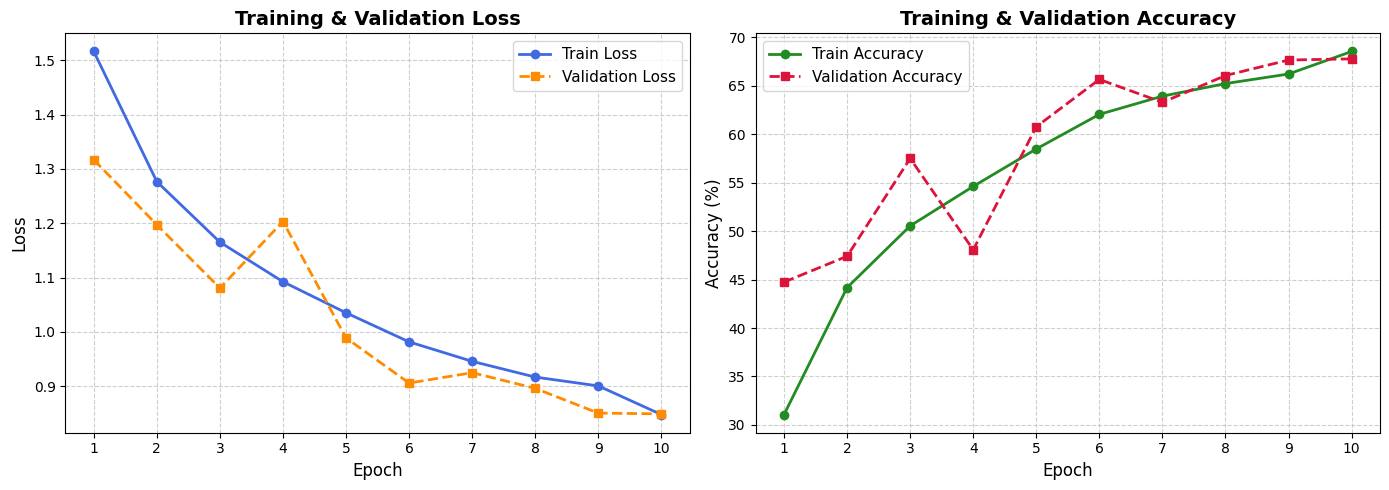

In [44]:
plot_graph_loss_acc(history_irnn)

Gradient Norm Statistics:
- Max gradient norm   : 4.0000
- Min gradient norm   : 2.206728
- Mean gradient norm  : 3.9789
- Median gradient norm: 4.0000


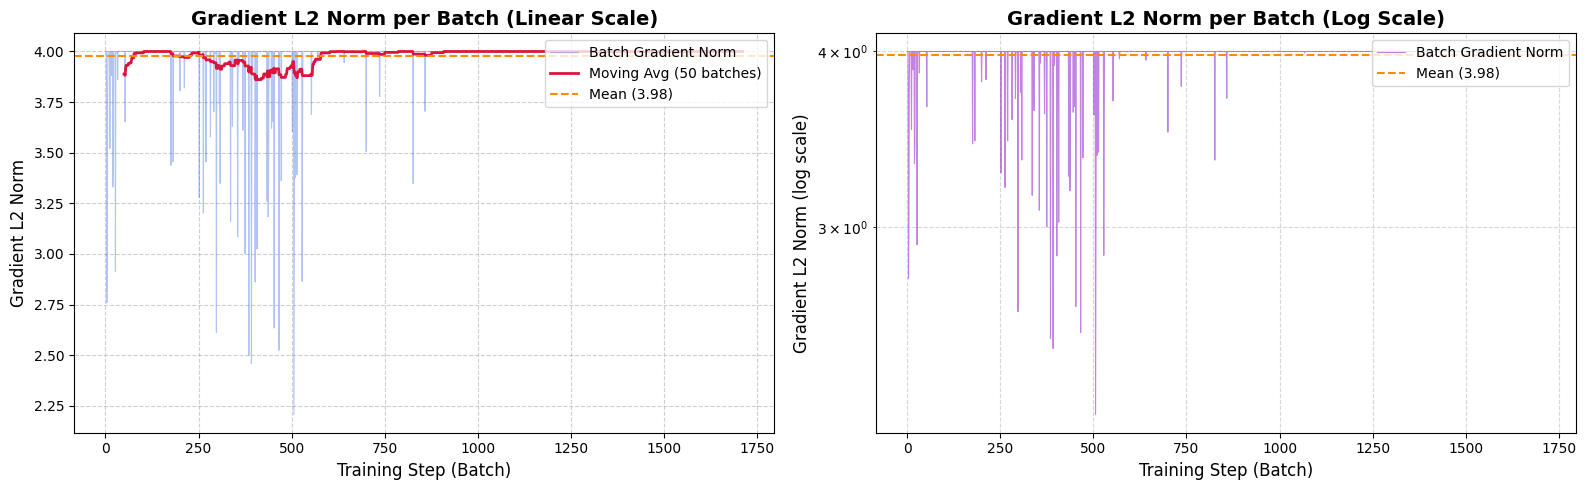

In [45]:
plot_graph_grad(history_irnn)